In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
discovery = np.load('/sietch_colab/akapoor/XPopVAE/experiments/IM_symmetric/processed_data/discovery_train.npy')

In [3]:
discovery.shape

(4000, 7183)

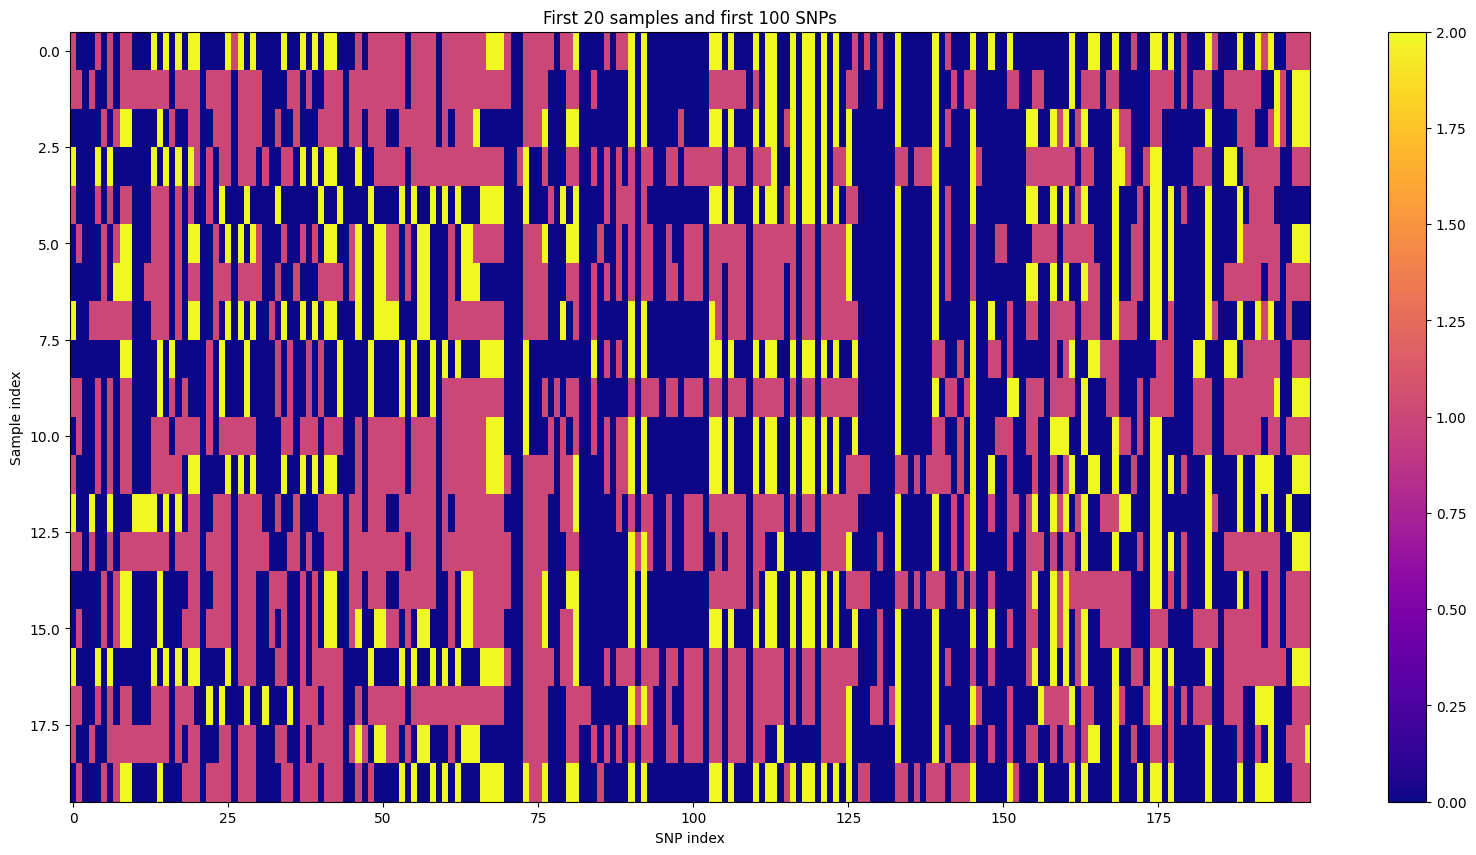

In [9]:
# Do an imshow of the first 20 samples and for the first 100 SNPs
plt.figure(figsize=(20, 10))
plt.imshow(discovery[:20, :200], aspect='auto', cmap='plasma')
plt.colorbar()
plt.title('First 20 samples and first 100 SNPs')
plt.xlabel('SNP index')
plt.ylabel('Sample index')
plt.show()

In [10]:
np.unique(discovery[:20, :200])

array([0., 1., 2.], dtype=float32)

In [1]:
import numpy as np
import torch 
import matplotlib.pyplot as plt

In [2]:
val_recon = np.load('/sietch_colab/akapoor/XPopVAE/experiments/IM_symmetric/vae/ld_decay_val/reconstructed_genotypes_argmax.npy')

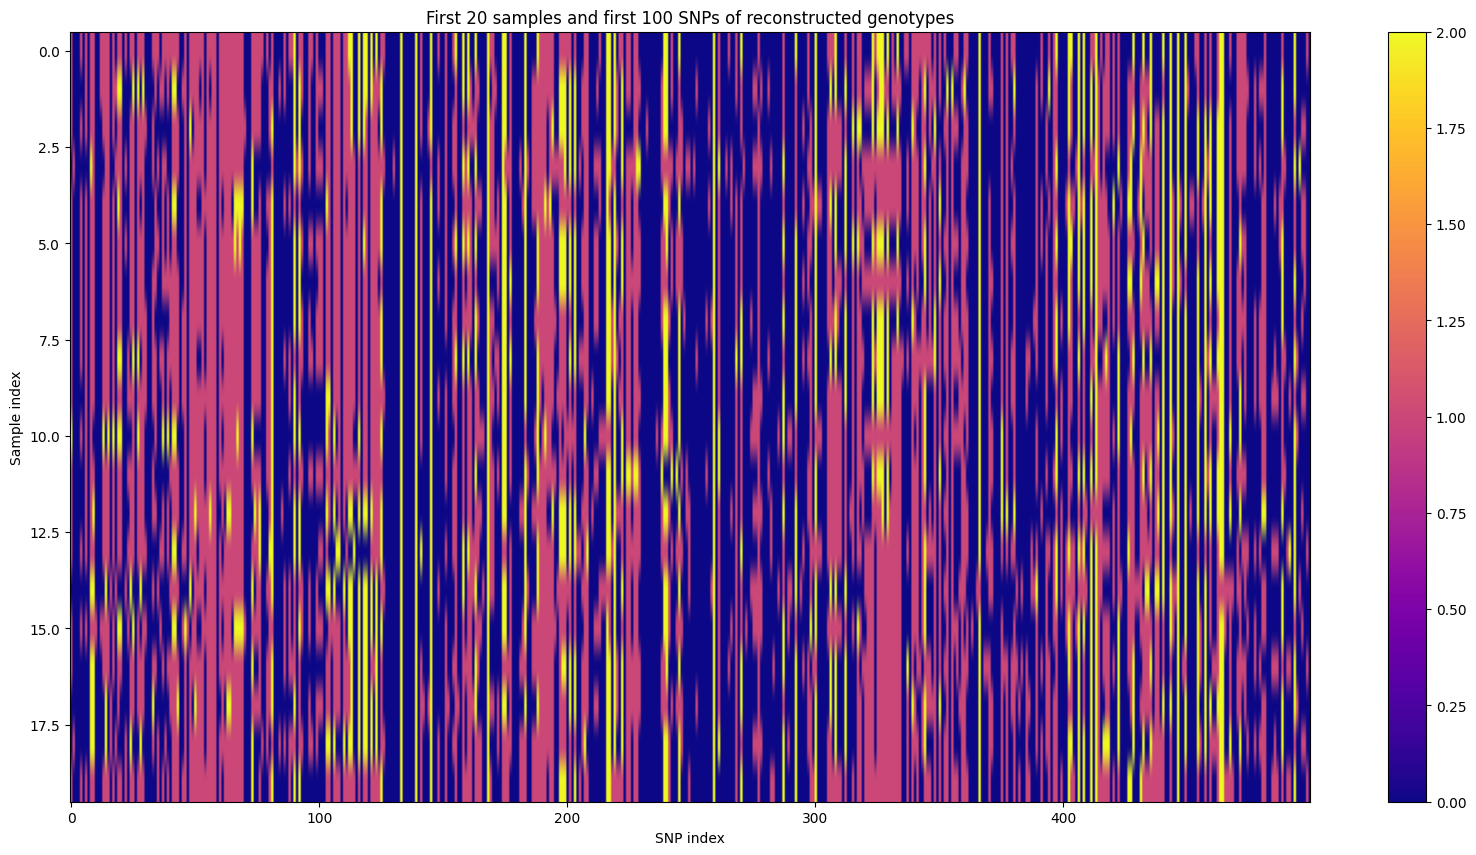

In [ ]:
# create a heatmap of reconstructed genotypes for the first 20 samples and for the first 100 SNPs
plt.figure(figsize=(20, 10))
plt.imshow(val_recon[:20, :500], aspect='auto', cmap='plasma')
plt.colorbar()
plt.title('First 20 samples and first 500 SNPs of reconstructed genotypes')
plt.xlabel('SNP index')
plt.ylabel('Sample index')
plt.show()

In [10]:
val_gt = np.load('/sietch_colab/akapoor/XPopVAE/experiments/IM_symmetric/processed_data/discovery_val.npy')

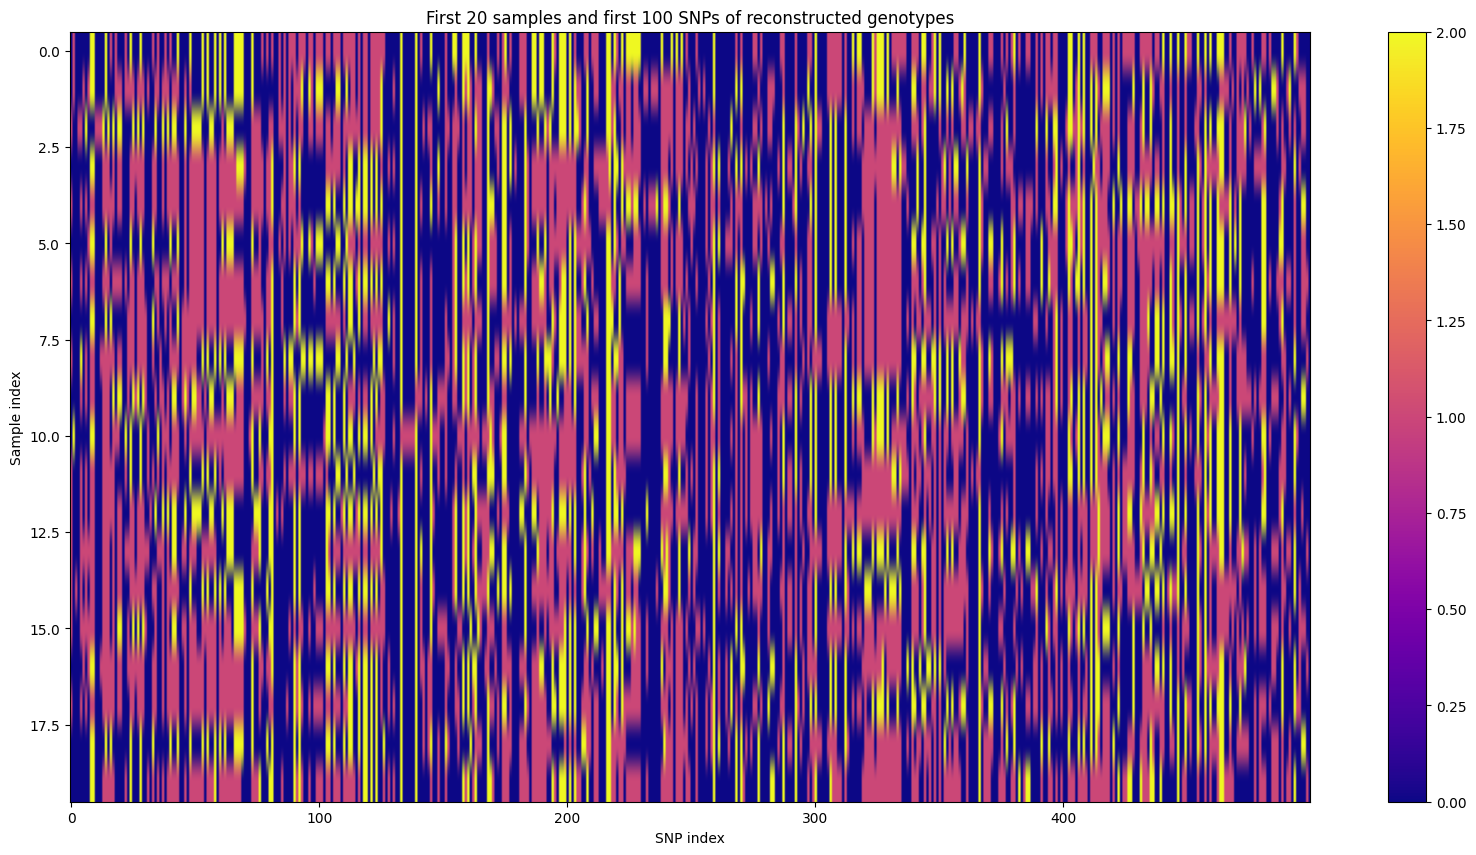

In [11]:
# create a heatmap of ground truth genotypes for the first 20 samples and for the first 100 SNPs
plt.figure(figsize=(20, 10))
plt.imshow(val_gt[:20, :500], aspect='auto', cmap='plasma')
plt.colorbar()
plt.title('First 20 samples and first 100 SNPs of reconstructed genotypes')
plt.xlabel('SNP index')
plt.ylabel('Sample index')
plt.show()

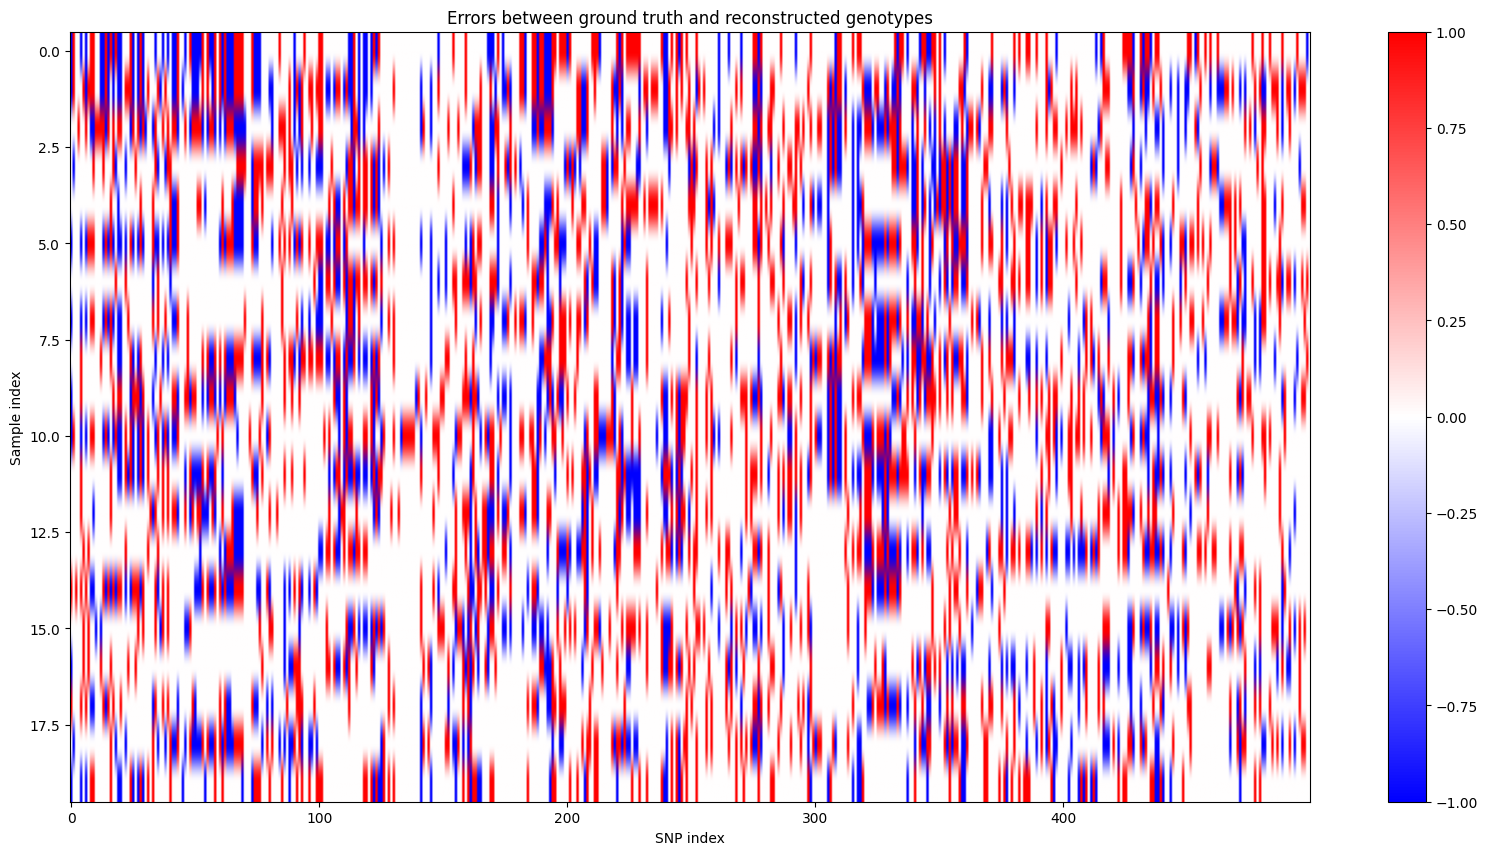

In [13]:
# Visualize the errors between the two 
errors = val_gt[:20, :500] - val_recon[:20, :500]
plt.figure(figsize=(20, 10))
plt.imshow(errors, aspect='auto', cmap='bwr', vmin=-1, vmax=1)
plt.colorbar()
plt.title('Errors between ground truth and reconstructed genotypes')
plt.xlabel('SNP index')
plt.ylabel('Sample index')
plt.show()

In [14]:
# i want to see the max and min of the column means for the validation ground truth 
col_means = np.mean(val_gt, axis=0)
print(f'Min of column means: {np.min(col_means)}')
print(f'Max of column means: {np.max(col_means)}')

Min of column means: 0.0
Max of column means: 1.930999994277954


In [22]:
# Scratch code for phenotype prediction using the latent representations from the model 
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset

def extract_latent_mu(model, G, batch_size=128, device="cpu"):
    """
    Extract latent mean vectors mu from a trained VAE.

    Parameters
    ----------
    model : torch.nn.Module
    G : np.ndarray
        Shape (n_individuals, n_snps)
    batch_size : int
    device : str

    Returns
    -------
    np.ndarray
        Shape (n_individuals, latent_dim)
    """
    device = torch.device(device)
    model.eval()

    X = torch.tensor(G, dtype=torch.float32).unsqueeze(1)  # (N, 1, L)
    loader = DataLoader(TensorDataset(X), batch_size=batch_size, shuffle=False)

    mu_all = []

    with torch.no_grad():
        for (x,) in loader:
            x = x.to(device)
            logits, mu, logvar, z = model(x)
            mu_all.append(mu.cpu().numpy())

    return np.concatenate(mu_all, axis=0)

In [23]:
import torch
import yaml
import sys
from pathlib import Path

sys.path.append(str(Path("/sietch_colab/akapoor/XPopVAE")))
from src.model import ConvVAE


def load_model_from_checkpoint(checkpoint_path, device="cpu"):
    """
    Load ConvVAE from a checkpoint dict containing:
      - model_state_dict
      - vae_config
      - input_length
    """
    device = torch.device(device)
    checkpoint = torch.load(checkpoint_path, map_location=device)

    vae_config = checkpoint["vae_config"]
    input_length = int(checkpoint["input_length"])

    model = ConvVAE(
        input_length=input_length,
        in_channels=1,
        hidden_channels=vae_config["model"]["hidden_channels"],
        kernel_size=int(vae_config["model"]["kernel_size"]),
        stride=int(vae_config["model"]["stride"]),
        padding=int(vae_config["model"]["padding"]),
        latent_dim=int(vae_config["model"]["latent_dim"]),
        use_batchnorm=bool(vae_config["model"].get("use_batchnorm", False)),
        activation=vae_config["model"].get("activation", "elu"),
    ).to(device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model

In [25]:
import numpy as np
import torch

G = np.load("/sietch_colab/akapoor/XPopVAE/experiments/IM_symmetric/processed_data/0/rep0/discovery_val.npy")

device = "cuda" if torch.cuda.is_available() else "cpu"

model = load_model_from_checkpoint(
    "/sietch_colab/akapoor/XPopVAE/experiments/IM_symmetric/vae/vae_outputs/checkpoints/best_model.pt",
    device=device,
)

latent_mu = extract_latent_mu(model, G, batch_size=128, device=device)

print(latent_mu.shape)
np.save("latent_mu_discovery_val.npy", latent_mu)

(1000, 256)


In [26]:
G = np.load("/sietch_colab/akapoor/XPopVAE/experiments/IM_symmetric/processed_data/0/rep0/discovery_train.npy")

device = "cuda" if torch.cuda.is_available() else "cpu"

model = load_model_from_checkpoint(
    "/sietch_colab/akapoor/XPopVAE/experiments/IM_symmetric/vae/vae_outputs/checkpoints/best_model.pt",
    device=device,
)

latent_mu = extract_latent_mu(model, G, batch_size=128, device=device)

print(latent_mu.shape)
np.save("latent_mu_discovery_train.npy", latent_mu)


(4000, 256)


In [27]:
G = np.load("/sietch_colab/akapoor/XPopVAE/experiments/IM_symmetric/processed_data/0/rep0/target.npy")

device = "cuda" if torch.cuda.is_available() else "cpu"

model = load_model_from_checkpoint(
    "/sietch_colab/akapoor/XPopVAE/experiments/IM_symmetric/vae/vae_outputs/checkpoints/best_model.pt",
    device=device,
)

latent_mu = extract_latent_mu(model, G, batch_size=128, device=device)

print(latent_mu.shape)
np.save("latent_mu_target.npy", latent_mu)

(5000, 256)


In [28]:
# Load in latent_mu for discovery_val and target and train. Stack the discovery_val and discovery_train together and then do a PCA on the combined latent representations. 
latent_mu_discovery_val = np.load("latent_mu_discovery_val.npy")
latent_mu_discovery_train = np.load("latent_mu_discovery_train.npy")
latent_mu_target = np.load("latent_mu_target.npy")

combined_latent = np.vstack([latent_mu_discovery_train, latent_mu_discovery_val])

In [30]:
import pickle
with open('/sietch_colab/akapoor/XPopVAE/experiments/IM_symmetric/simulations/0/rep0/phenotype.pkl', 'rb') as f:
    phenotype = pickle.load(f)

/tmp/ipykernel_3633914/2747563586.py:3: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  phenotype = pickle.load(f)


In [31]:
phenotype

,individual_id,population,genetic_value,environmental_noise,phenotype
0,0,YRI,1.199589,-1.524912,-0.325323
1,1,YRI,1.250842,-2.706419,-1.455577
2,2,YRI,1.450261,-1.906728,-0.456466
3,3,YRI,2.900523,3.617596,6.518119
4,4,YRI,2.900523,-3.180166,-0.279643
...,...,...,...,...,...
9995,9995,CEU,-0.983916,-0.521593,-1.505509
9996,9996,CEU,0.000000,0.220819,0.220819
9997,9997,CEU,-2.552911,-1.347703,-3.900615
9998,9998,CEU,-4.770028,-0.055494,-4.825522


In [33]:
ceu_phenotype = phenotype.loc[phenotype['population'] == 'CEU', 'phenotype']

In [35]:
ceu_phenotype

5000   -5.610649
5001   -3.048366
5002   -1.671647
5003   -1.338589
5004   -0.492524
          ...   
9995   -1.505509
9996    0.220819
9997   -3.900615
9998   -4.825522
9999   -4.190603
Name: phenotype, Length: 5000, dtype: float64

In [34]:
yri_phenotype = phenotype.loc[phenotype['population'] == 'YRI', 'phenotype']

In [36]:
# Train a linear regression model to predict the phenotype. Then take that trained model and evaluate it on the target set. Report the R^2 score.
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = combined_latent
y = ceu_phenotype.values

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)
print("R^2 score:", r2_score(y, y_pred))


R^2 score: 0.058907073120484266


In [37]:
# Wait the linear regression gives pretty bad results 
y_pred

array([-4.3994555, -4.185304 , -2.801282 , ..., -3.5092793, -2.6737251,
       -3.8027372], shape=(5000,), dtype=float32)

In [38]:
y

array([-5.61064921, -3.04836559, -1.67164743, ..., -3.90061491,
       -4.82552196, -4.19060322], shape=(5000,))

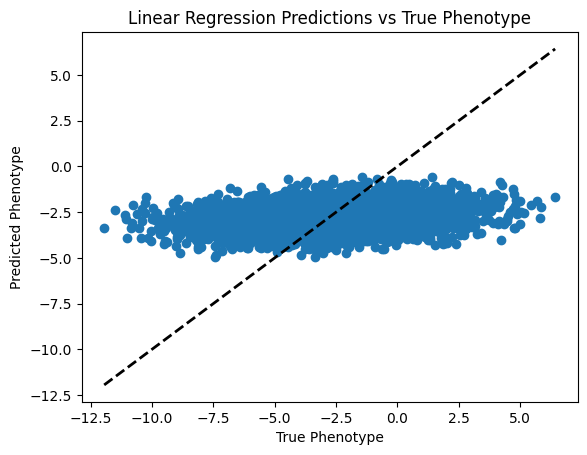

In [40]:
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(y, y_pred)
# Plot the y= x line for reference
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('True Phenotype')
plt.ylabel('Predicted Phenotype')
plt.title('Linear Regression Predictions vs True Phenotype')
plt.show()

### See how good the learned representations are for LD 

In [39]:
from pathlib import Path 
import torch 
import sys 
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
sys.path.append(str(Path("/sietch_colab/akapoor/XPopVAE")))
from src.model import ConvVAE

def load_model_from_checkpoint(checkpoint_path: Path, device: torch.device) -> ConvVAE:
    checkpoint = torch.load(checkpoint_path, map_location=device)

    vae_config = checkpoint["vae_config"]
    input_length = int(checkpoint["input_length"])

    model = ConvVAE(
        input_length=input_length,
        in_channels=1,
        hidden_channels=vae_config["model"]["hidden_channels"],
        kernel_size=int(vae_config["model"]["kernel_size"]),
        stride=int(vae_config["model"]["stride"]),
        padding=int(vae_config["model"]["padding"]),
        latent_dim=int(vae_config["model"]["latent_dim"]),
        use_batchnorm=False,
        activation="elu",
    ).to(device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model

In [42]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
checkpoint_path = '/sietch_colab/akapoor/XPopVAE/experiments/IM_symmetric/vae/default/vae_outputs/checkpoints/final_model.pt'
genotype_npy = '/sietch_colab/akapoor/XPopVAE/experiments/IM_symmetric/vae/default/vae_outputs/masked_validation_dataset.npy'

print(f"Loading checkpoint: {checkpoint_path}")
model = load_model_from_checkpoint(checkpoint_path, device)

print(f"Loading genotype matrix: {genotype_npy}")
G_truth = np.load(genotype_npy)
if G_truth.ndim != 2:
    G_truth = np.squeeze(G_truth)

print(f"Genotype matrix shape: {G_truth.shape}")


Using device: cuda
Loading checkpoint: /sietch_colab/akapoor/XPopVAE/experiments/IM_symmetric/vae/default/vae_outputs/checkpoints/final_model.pt
Loading genotype matrix: /sietch_colab/akapoor/XPopVAE/experiments/IM_symmetric/vae/default/vae_outputs/masked_validation_dataset.npy
Genotype matrix shape: (1000, 7187)


In [43]:
def reconstruct_argmax_genotypes(
    model: torch.nn.Module,
    G: np.ndarray,
    device: torch.device,
    batch_size: int = 128,
) -> np.ndarray:
    X = torch.tensor(G, dtype=torch.float32).unsqueeze(1)  # (N,1,L)
    ds = TensorDataset(X)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)

    recon_batches = []

    with torch.no_grad():
        for (x,) in loader:
            x = x.to(device)
            logits, mu, logvar, z = model(x)   # (B,3,L)
            pred = torch.argmax(logits, dim=1) # (B,L)
            recon_batches.append(pred.cpu().numpy())

    return np.concatenate(recon_batches, axis=0)

In [44]:
print("Reconstructing genotype matrix with argmax...")
G_recon = reconstruct_argmax_genotypes(
    model=model,
    G=G_truth,
    device=device,
    batch_size=128,
)

Reconstructing genotype matrix with argmax...


In [49]:
mask_path = '/sietch_colab/akapoor/XPopVAE/experiments/IM_symmetric/vae/default/vae_outputs/validation_masks.npy'
mask = np.load(mask_path)

print("Mask shape:", mask.shape)
print("Unique mask values:", np.unique(mask))

if mask.shape != G_truth.shape:
    raise ValueError(f"Mask shape {mask.shape} does not match genotype shape {G_truth.shape}")

# assume 1 = masked, 0 = unmasked
masked_bool = mask.astype(bool)

# keep only masked entries; everything else becomes NaN
G_recon_masked_only = np.where(masked_bool, G_recon, np.nan)
G_truth_masked_only = np.where(masked_bool, G_truth, np.nan)

Mask shape: (1000, 7187)
Unique mask values: [False  True]


In [45]:
G_recon.shape

(1000, 7187)

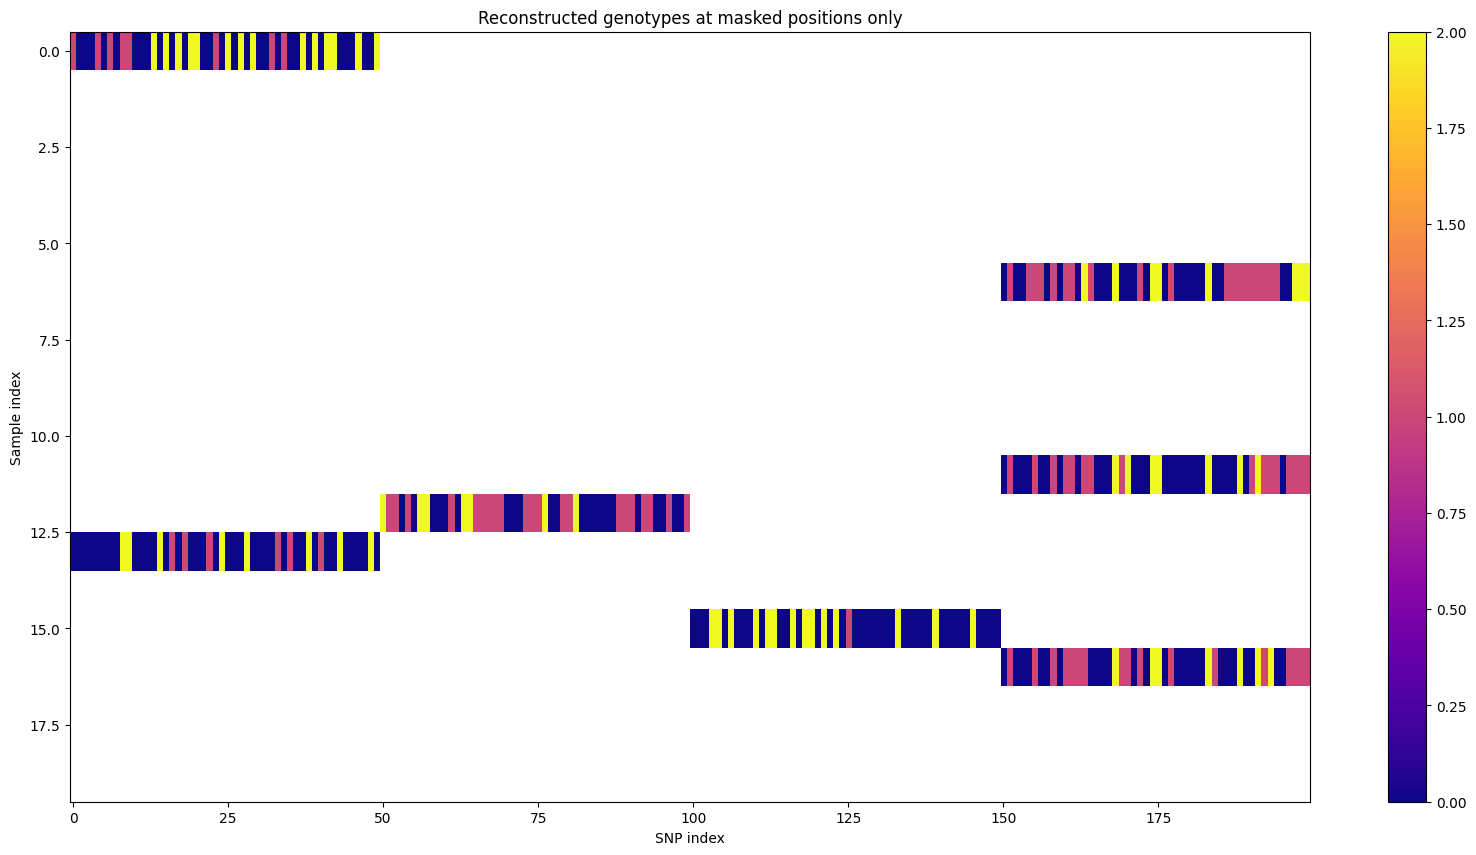

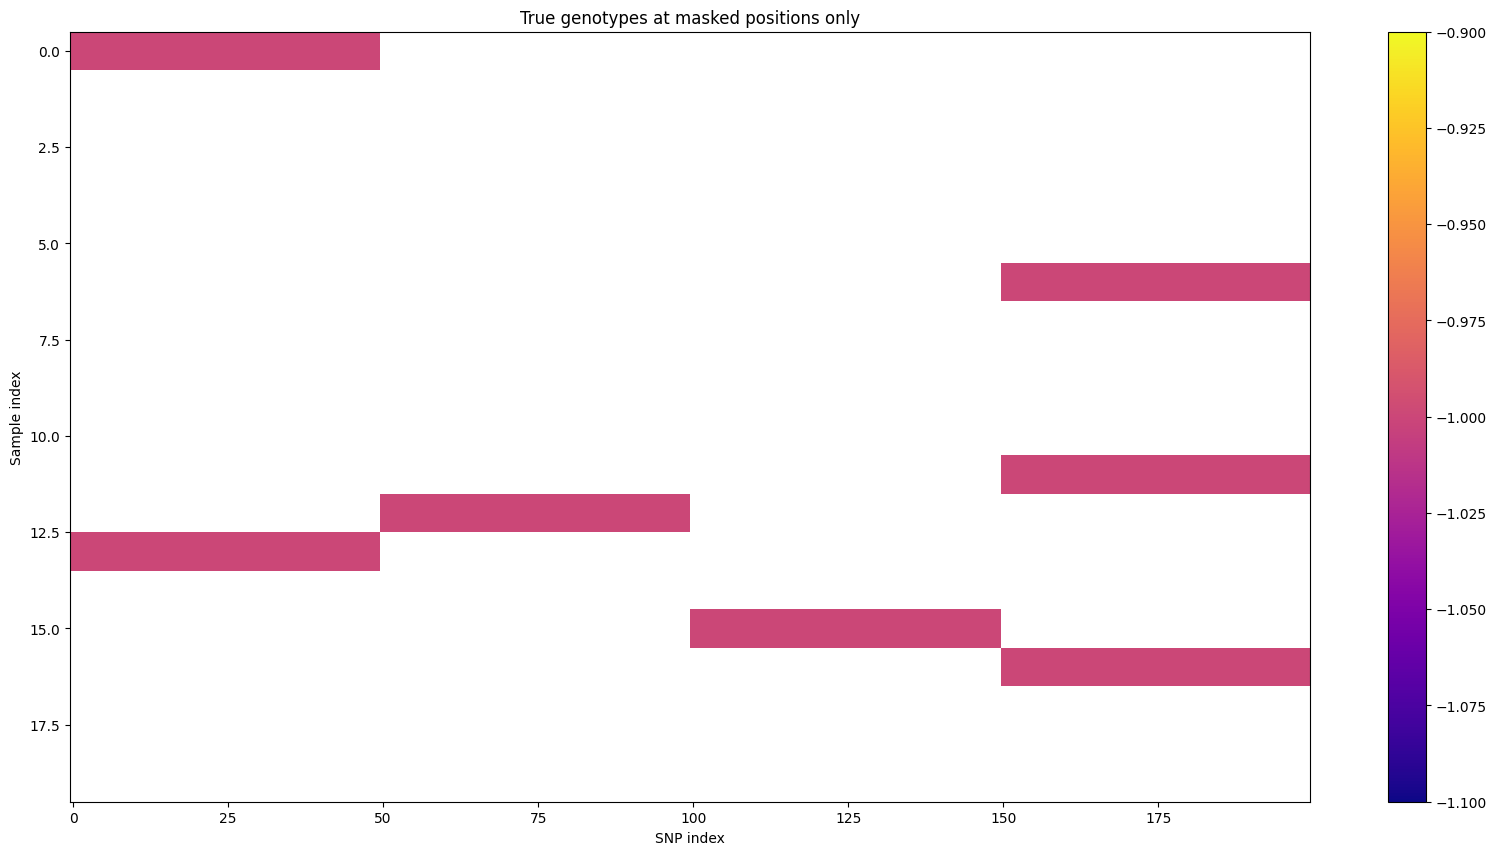

In [50]:
plt.figure(figsize=(20, 10))
plt.imshow(G_recon_masked_only[:20, :200], aspect='auto', cmap='plasma')
plt.colorbar()
plt.title('Reconstructed genotypes at masked positions only')
plt.xlabel('SNP index')
plt.ylabel('Sample index')
plt.show()

plt.figure(figsize=(20, 10))
plt.imshow(G_truth_masked_only[:20, :200], aspect='auto', cmap='plasma')
plt.colorbar()
plt.title('True genotypes at masked positions only')
plt.xlabel('SNP index')
plt.ylabel('Sample index')
plt.show()

In [35]:
model

ConvVAE(
  (encoder): Sequential(
    (0): Conv1d(1, 32, kernel_size=(17,), stride=(2,), padding=(8,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(32, 64, kernel_size=(17,), stride=(2,), padding=(8,))
    (3): ELU(alpha=1.0)
    (4): Conv1d(64, 128, kernel_size=(17,), stride=(2,), padding=(8,))
    (5): ELU(alpha=1.0)
    (6): Conv1d(128, 256, kernel_size=(17,), stride=(2,), padding=(8,))
    (7): ELU(alpha=1.0)
    (8): Conv1d(256, 256, kernel_size=(17,), stride=(2,), padding=(8,))
    (9): ELU(alpha=1.0)
    (10): Conv1d(256, 256, kernel_size=(17,), stride=(2,), padding=(8,))
    (11): ELU(alpha=1.0)
  )
  (fc_mu): Linear(in_features=28928, out_features=256, bias=True)
  (fc_logvar): Linear(in_features=28928, out_features=256, bias=True)
  (fc_decode): Linear(in_features=256, out_features=28928, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose1d(256, 256, kernel_size=(17,), stride=(2,), padding=(8,))
    (1): ELU(alpha=1.0)
    (2): ConvTranspose1d(256, 256, kernel_size=(17,), 

In [36]:
import numpy as np
import torch
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = load_model_from_checkpoint(checkpoint_path, device)

G_truth = np.load(genotype_npy)
if G_truth.ndim != 2:
    raise ValueError(f"Expected genotype matrix of shape (n_individuals, n_snps), got {G_truth.shape}")

# convert to tensor: (batch, channels, length)
x = torch.tensor(G_truth, dtype=torch.float32).unsqueeze(1).to(device)

model.eval()
with torch.no_grad():
    h = model.encoder(x)                  # (N, C, L_enc)
    h_flat = h.view(h.size(0), -1)        # (N, C * L_enc)
    mu = model.fc_mu(h_flat)              # (N, latent_dim)
    logvar = model.fc_logvar(h_flat)      # (N, latent_dim)

latent_mu = mu.cpu().numpy()
latent_logvar = logvar.cpu().numpy()

print("latent_mu shape:", latent_mu.shape)
print("latent_logvar shape:", latent_logvar.shape)

latent_mu shape: (4000, 256)
latent_logvar shape: (4000, 256)


Using device: cuda
Loading checkpoint: /sietch_colab/akapoor/XPopVAE/experiments/IM_symmetric/vae/default/vae_outputs/checkpoints/final_model.pt
G_input shape: (1000, 5514)
G_true shape: (1000, 5514)
mask shape: (1000, 5514)
Unique mask values: [False  True]
Reconstructing from masked input...
Masked-position accuracy: 0.9844
Masked positions: 550000
Wrong masked predictions: 8571


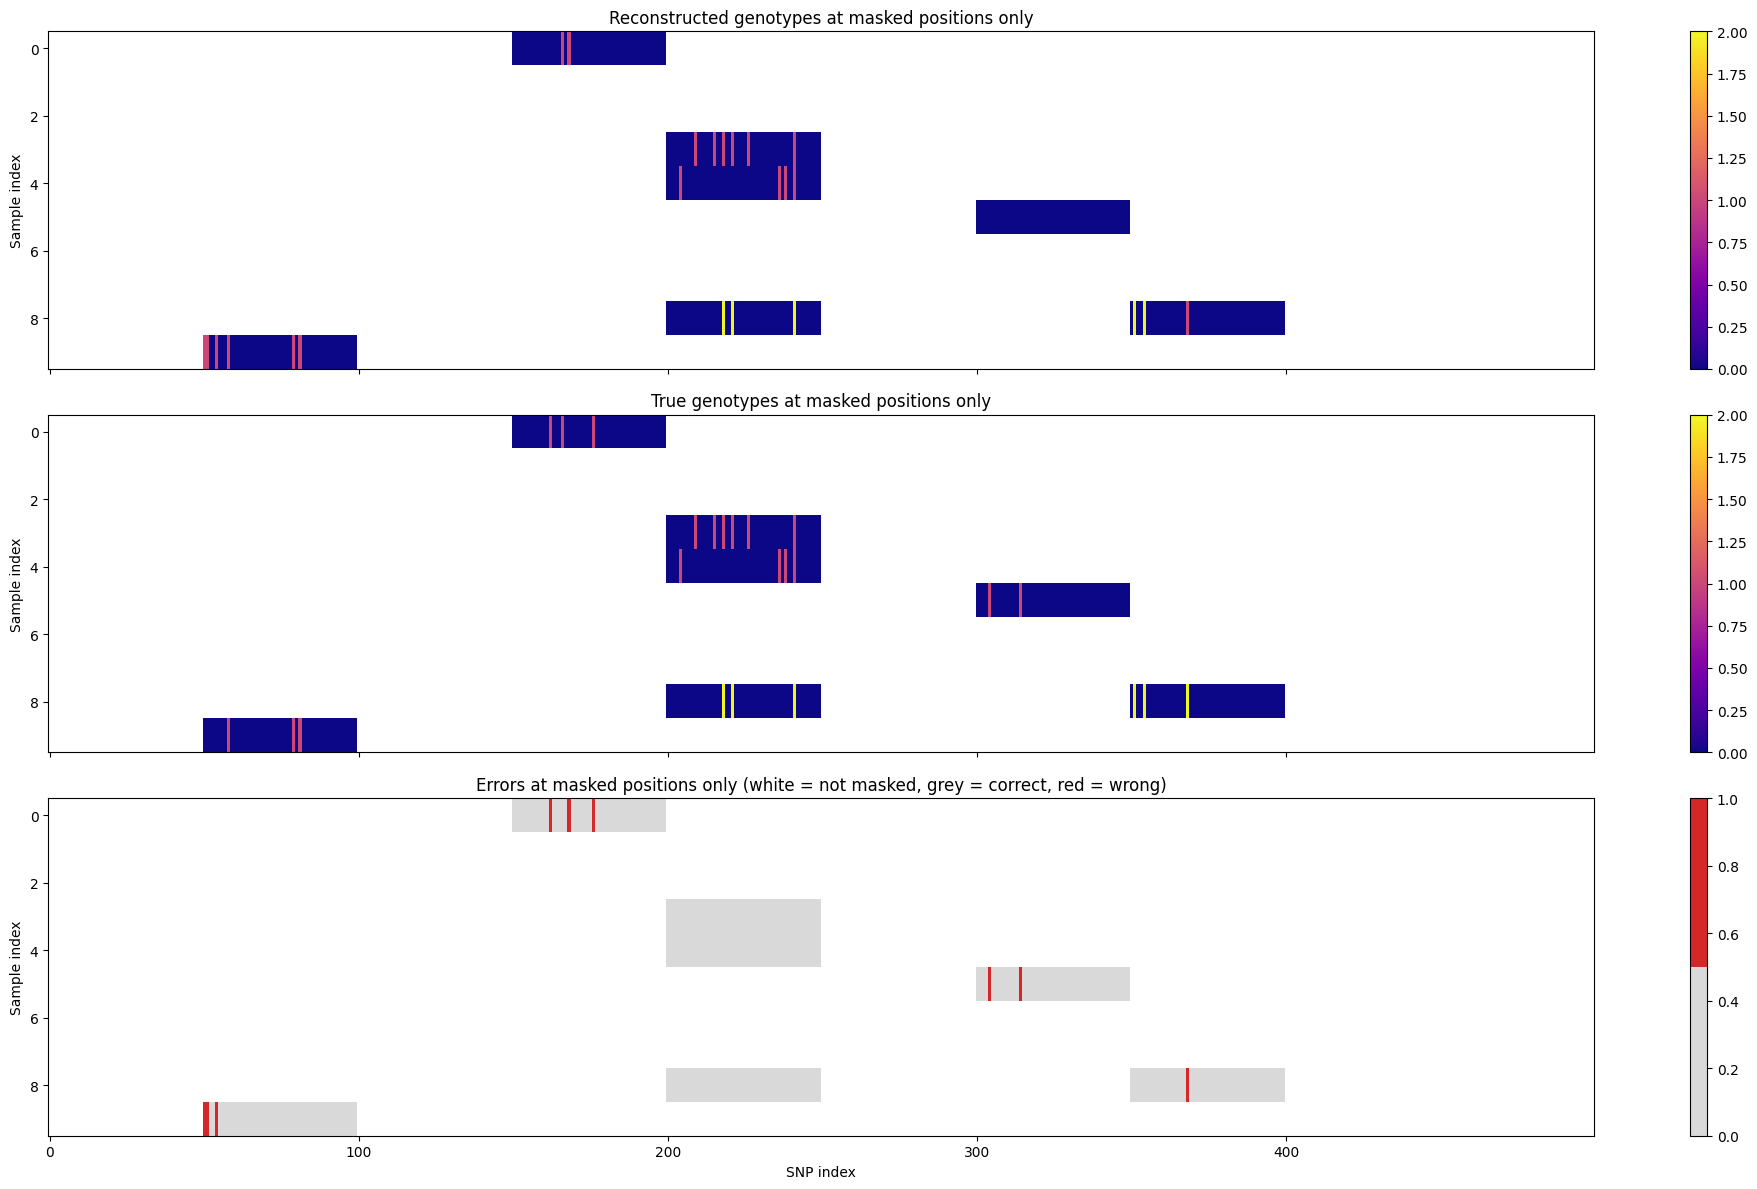

In [140]:
from pathlib import Path
import torch
import sys
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

sys.path.append(str(Path("/sietch_colab/akapoor/XPopVAE")))
from src.model import ConvVAE


def load_model_from_checkpoint(checkpoint_path: Path, device: torch.device) -> ConvVAE:
    checkpoint = torch.load(checkpoint_path, map_location=device)

    vae_config = checkpoint["vae_config"]
    input_length = int(checkpoint["input_length"])

    model = ConvVAE(
        input_length=input_length,
        in_channels=1,
        hidden_channels=vae_config["model"]["hidden_channels"],
        kernel_size=int(vae_config["model"]["kernel_size"]),
        stride=int(vae_config["model"]["stride"]),
        padding=int(vae_config["model"]["padding"]),
        latent_dim=int(vae_config["model"]["latent_dim"]),
        use_batchnorm=False,
        activation="elu",
    ).to(device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model


def reconstruct_argmax_genotypes(
    model: torch.nn.Module,
    G: np.ndarray,
    device: torch.device,
    batch_size: int = 128,
) -> np.ndarray:
    X = torch.tensor(G, dtype=torch.float32).unsqueeze(1)  # (N,1,L)
    ds = TensorDataset(X)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)

    recon_batches = []

    with torch.no_grad():
        for (x,) in loader:
            x = x.to(device)
            logits, mu, logvar, z = model(x)
            pred = torch.argmax(logits, dim=1)  # (B,L)
            recon_batches.append(pred.cpu().numpy())

    return np.concatenate(recon_batches, axis=0)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

checkpoint_path = '/sietch_colab/akapoor/XPopVAE/experiments/IM_symmetric/vae/default/vae_outputs/checkpoints/final_model.pt'
masked_input_npy = '/sietch_colab/akapoor/XPopVAE/experiments/IM_symmetric/vae/default/vae_outputs/masked_validation_dataset.npy'
truth_npy = '/sietch_colab/akapoor/XPopVAE/experiments/IM_symmetric/processed_data/0/rep0/discovery_val.npy'
mask_path = '/sietch_colab/akapoor/XPopVAE/experiments/IM_symmetric/vae/default/vae_outputs/validation_masks.npy'

print(f"Loading checkpoint: {checkpoint_path}")
model = load_model_from_checkpoint(checkpoint_path, device)

G_input = np.load(masked_input_npy)
G_true = np.load(truth_npy)
mask = np.load(mask_path)

if G_input.ndim != 2:
    G_input = np.squeeze(G_input)
if G_true.ndim != 2:
    G_true = np.squeeze(G_true)

print("G_input shape:", G_input.shape)
print("G_true shape:", G_true.shape)
print("mask shape:", mask.shape)
print("Unique mask values:", np.unique(mask))

if G_input.shape != G_true.shape:
    raise ValueError(f"G_input shape {G_input.shape} != G_true shape {G_true.shape}")
if mask.shape != G_true.shape:
    raise ValueError(f"mask shape {mask.shape} != G_true shape {G_true.shape}")

print("Reconstructing from masked input...")
G_recon = reconstruct_argmax_genotypes(
    model=model,
    G=G_input,
    device=device,
    batch_size=128,
)

masked_bool = mask.astype(bool)

# masked-only genotype views
G_recon_masked_plot = np.ma.masked_where(~masked_bool, G_recon)
G_true_masked_plot = np.ma.masked_where(~masked_bool, G_true)

# binary error map: 0 = correct, 1 = incorrect, only at masked positions
error_binary = (G_recon != G_true).astype(float)
error_masked_plot = np.ma.masked_where(~masked_bool, error_binary)

# optional summary
n_masked = masked_bool.sum()
n_wrong = ((G_recon != G_true) & masked_bool).sum()
masked_acc = 1.0 - (n_wrong / n_masked)
print(f"Masked-position accuracy: {masked_acc:.4f}")
print(f"Masked positions: {n_masked}")
print(f"Wrong masked predictions: {n_wrong}")

# plot a zoomed region
rows = slice(0, 10)
cols = slice(0, 500)

cmap_gt = plt.cm.plasma.copy()
cmap_gt.set_bad(color='white')


from matplotlib.colors import ListedColormap

cmap_err = ListedColormap(["#d9d9d9", "#d62728"])  # gray = correct, red = wrong
cmap_err.set_bad(color='white')

fig, axes = plt.subplots(3, 1, figsize=(20, 12), sharex=True)

im0 = axes[0].imshow(
    G_recon_masked_plot[rows, cols],
    aspect='auto',
    cmap=cmap_gt,
    vmin=0,
    vmax=2
)
axes[0].set_title('Reconstructed genotypes at masked positions only')
axes[0].set_ylabel('Sample index')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(
    G_true_masked_plot[rows, cols],
    aspect='auto',
    cmap=cmap_gt,
    vmin=0,
    vmax=2
)
axes[1].set_title('True genotypes at masked positions only')
axes[1].set_ylabel('Sample index')
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(
    error_masked_plot[rows, cols],
    aspect='auto',
    cmap=cmap_err,
    vmin=0,
    vmax=1
)
axes[2].set_title('Errors at masked positions only (white = not masked, grey = correct, red = wrong)')
axes[2].set_xlabel('SNP index')
axes[2].set_ylabel('Sample index')
fig.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

Using device: cuda
Loading checkpoint: /sietch_colab/akapoor/XPopVAE/experiments/IM_symmetric/vae/default/vae_outputs/checkpoints/final_model.pt
G_input shape: (5000, 5514)
G_true shape: (5000, 5514)
mask shape: (5000, 5514)
Unique mask values: [False  True]
Reconstructing from masked target input...
Masked-position accuracy (target): 0.9805
Masked positions (target): 2750000
Wrong masked predictions (target): 53559


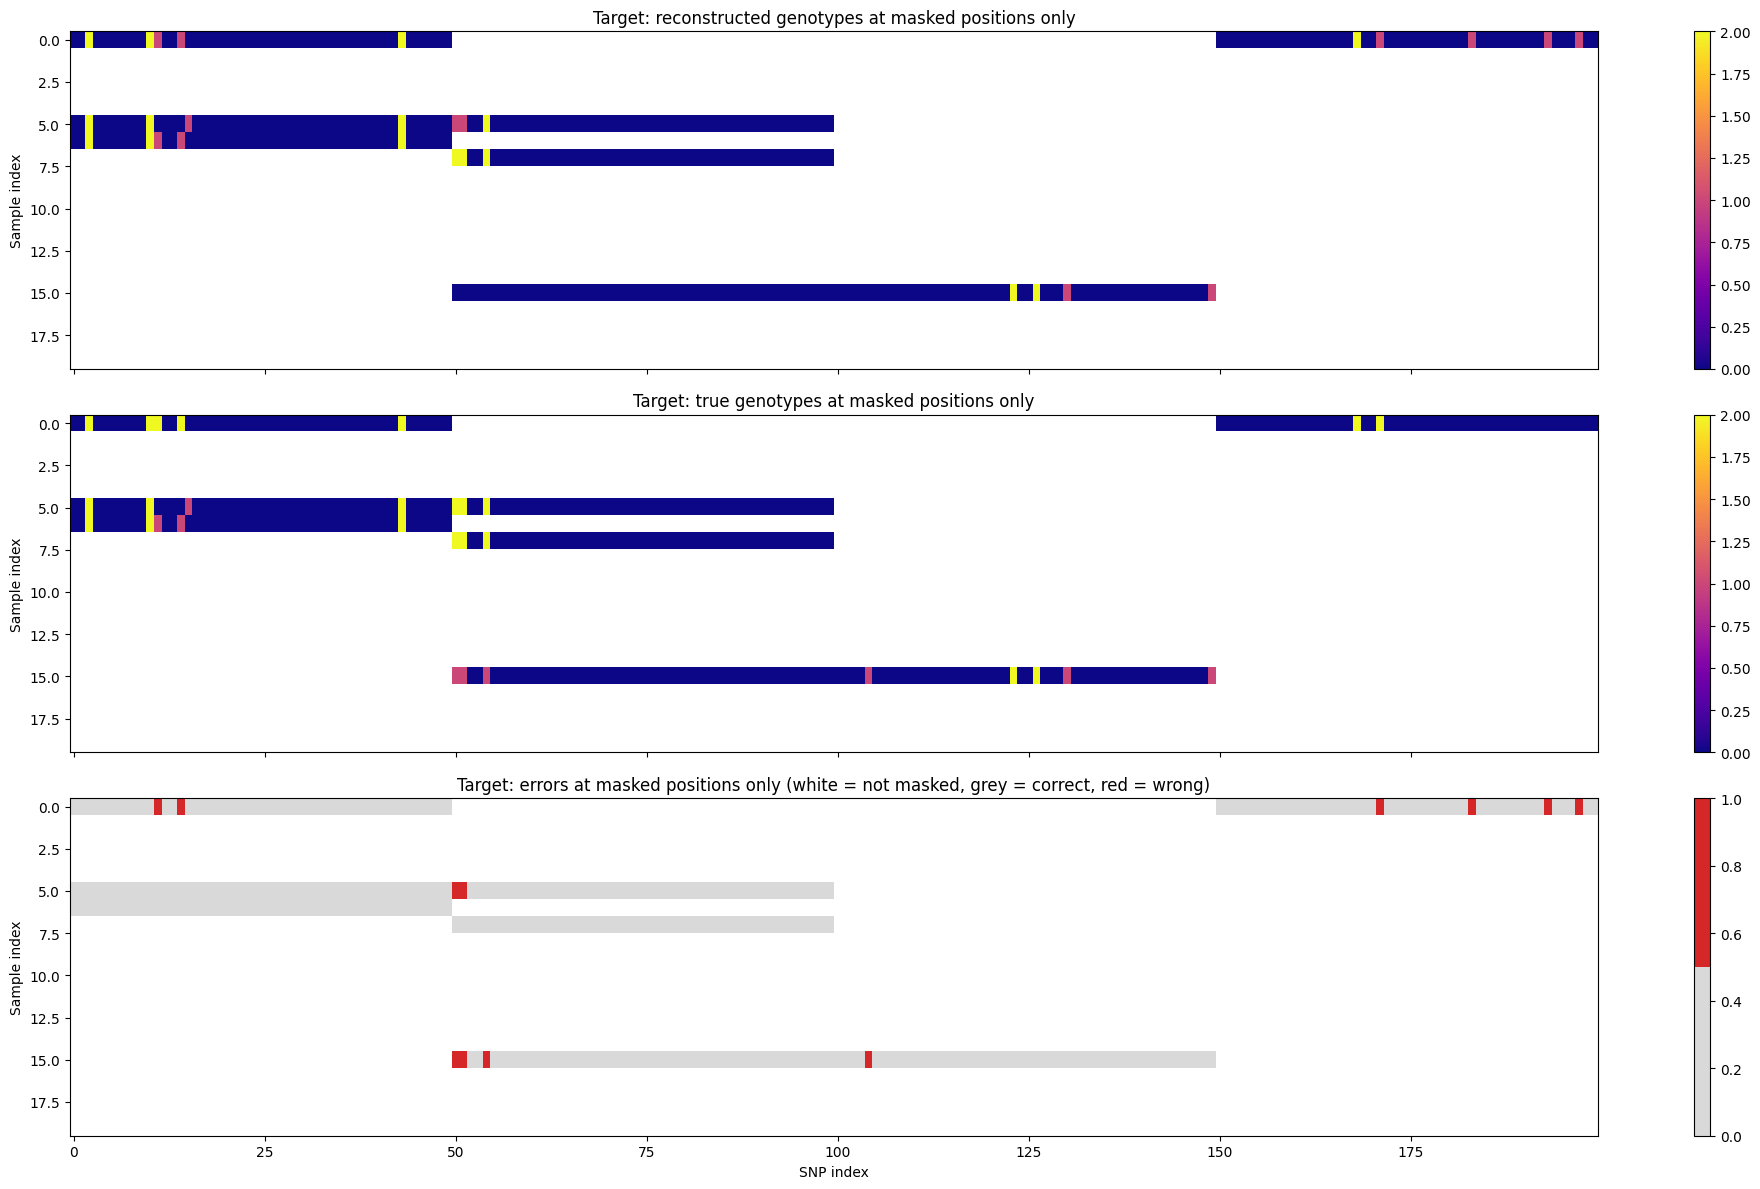

In [141]:
from pathlib import Path
import torch
import sys
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

sys.path.append(str(Path("/sietch_colab/akapoor/XPopVAE")))
from src.model import ConvVAE


def load_model_from_checkpoint(checkpoint_path: Path, device: torch.device) -> ConvVAE:
    checkpoint = torch.load(checkpoint_path, map_location=device)

    vae_config = checkpoint["vae_config"]
    input_length = int(checkpoint["input_length"])

    model = ConvVAE(
        input_length=input_length,
        in_channels=1,
        hidden_channels=vae_config["model"]["hidden_channels"],
        kernel_size=int(vae_config["model"]["kernel_size"]),
        stride=int(vae_config["model"]["stride"]),
        padding=int(vae_config["model"]["padding"]),
        latent_dim=int(vae_config["model"]["latent_dim"]),
        use_batchnorm=False,
        activation="elu",
    ).to(device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model


def reconstruct_argmax_genotypes(
    model: torch.nn.Module,
    G: np.ndarray,
    device: torch.device,
    batch_size: int = 128,
) -> np.ndarray:
    X = torch.tensor(G, dtype=torch.float32).unsqueeze(1)  # (N,1,L)
    ds = TensorDataset(X)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)

    recon_batches = []

    with torch.no_grad():
        for (x,) in loader:
            x = x.to(device)
            logits, mu, logvar, z = model(x)
            pred = torch.argmax(logits, dim=1)  # (B,L)
            recon_batches.append(pred.cpu().numpy())

    return np.concatenate(recon_batches, axis=0)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

checkpoint_path = '/sietch_colab/akapoor/XPopVAE/experiments/IM_symmetric/vae/default/vae_outputs/checkpoints/final_model.pt'
masked_input_npy = '/sietch_colab/akapoor/XPopVAE/experiments/IM_symmetric/vae/default/vae_outputs/masked_target_dataset.npy'
truth_npy = '/sietch_colab/akapoor/XPopVAE/experiments/IM_symmetric/processed_data/0/rep0/target.npy'
mask_path = '/sietch_colab/akapoor/XPopVAE/experiments/IM_symmetric/vae/default/vae_outputs/target_masks.npy'  # adjust if needed

print(f"Loading checkpoint: {checkpoint_path}")
model = load_model_from_checkpoint(checkpoint_path, device)

G_input = np.load(masked_input_npy)
G_true = np.load(truth_npy)
mask = np.load(mask_path)

if G_input.ndim != 2:
    G_input = np.squeeze(G_input)
if G_true.ndim != 2:
    G_true = np.squeeze(G_true)

print("G_input shape:", G_input.shape)
print("G_true shape:", G_true.shape)
print("mask shape:", mask.shape)
print("Unique mask values:", np.unique(mask))

if G_input.shape != G_true.shape:
    raise ValueError(f"G_input shape {G_input.shape} != G_true shape {G_true.shape}")
if mask.shape != G_true.shape:
    raise ValueError(f"mask shape {mask.shape} != G_true shape {G_true.shape}")

print("Reconstructing from masked target input...")
G_recon = reconstruct_argmax_genotypes(
    model=model,
    G=G_input,
    device=device,
    batch_size=128,
)

masked_bool = mask.astype(bool)

G_recon_masked_plot = np.ma.masked_where(~masked_bool, G_recon)
G_true_masked_plot = np.ma.masked_where(~masked_bool, G_true)

error_binary = (G_recon != G_true).astype(float)
error_masked_plot = np.ma.masked_where(~masked_bool, error_binary)

n_masked = masked_bool.sum()
n_wrong = ((G_recon != G_true) & masked_bool).sum()
masked_acc = 1.0 - (n_wrong / n_masked)

print(f"Masked-position accuracy (target): {masked_acc:.4f}")
print(f"Masked positions (target): {n_masked}")
print(f"Wrong masked predictions (target): {n_wrong}")

rows = slice(0, 20)
cols = slice(0, 200)

cmap_gt = plt.cm.plasma.copy()
cmap_gt.set_bad(color='white')

cmap_err = ListedColormap(["#d9d9d9", "#d62728"])  # gray = correct, red = wrong
cmap_err.set_bad(color='white')

fig, axes = plt.subplots(3, 1, figsize=(20, 12), sharex=True)

im0 = axes[0].imshow(
    G_recon_masked_plot[rows, cols],
    aspect='auto',
    cmap=cmap_gt,
    vmin=0,
    vmax=2
)
axes[0].set_title('Target: reconstructed genotypes at masked positions only')
axes[0].set_ylabel('Sample index')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(
    G_true_masked_plot[rows, cols],
    aspect='auto',
    cmap=cmap_gt,
    vmin=0,
    vmax=2
)
axes[1].set_title('Target: true genotypes at masked positions only')
axes[1].set_ylabel('Sample index')
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(
    error_masked_plot[rows, cols],
    aspect='auto',
    cmap=cmap_err,
    vmin=0,
    vmax=1
)
axes[2].set_title('Target: errors at masked positions only (white = not masked, grey = correct, red = wrong)')
axes[2].set_xlabel('SNP index')
axes[2].set_ylabel('Sample index')
fig.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

In [130]:
from pathlib import Path
import torch
import sys
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

sys.path.append(str(Path("/sietch_colab/akapoor/XPopVAE")))
from src.model import ConvVAE


def load_model_from_checkpoint(checkpoint_path: Path, device: torch.device) -> ConvVAE:
    checkpoint = torch.load(checkpoint_path, map_location=device)

    vae_config = checkpoint["vae_config"]
    input_length = int(checkpoint["input_length"])

    model = ConvVAE(
        input_length=input_length,
        in_channels=1,
        hidden_channels=vae_config["model"]["hidden_channels"],
        kernel_size=int(vae_config["model"]["kernel_size"]),
        stride=int(vae_config["model"]["stride"]),
        padding=int(vae_config["model"]["padding"]),
        latent_dim=int(vae_config["model"]["latent_dim"]),
        use_batchnorm=False,
        activation="elu",
    ).to(device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model


def reconstruct_argmax_genotypes(
    model: torch.nn.Module,
    G: np.ndarray,
    device: torch.device,
    batch_size: int = 128,
) -> np.ndarray:
    X = torch.tensor(G, dtype=torch.float32).unsqueeze(1)  # (N,1,L)
    ds = TensorDataset(X)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)

    recon_batches = []

    with torch.no_grad():
        for (x,) in loader:
            x = x.to(device)
            logits, mu, logvar, z = model(x)
            pred = torch.argmax(logits, dim=1)  # (B,L)
            recon_batches.append(pred.cpu().numpy())

    return np.concatenate(recon_batches, axis=0)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

checkpoint_path = '/sietch_colab/akapoor/XPopVAE/experiments/IM_symmetric/vae/default/vae_outputs/checkpoints/final_model.pt'
masked_input_npy = '/sietch_colab/akapoor/XPopVAE/experiments/IM_symmetric/processed_data/0/rep0/discovery_val.npy'
truth_npy = '/sietch_colab/akapoor/XPopVAE/experiments/IM_symmetric/processed_data/0/rep0/discovery_val.npy'

Using device: cuda


In [131]:
print(f"Loading checkpoint: {checkpoint_path}")
model = load_model_from_checkpoint(checkpoint_path, device)

G_input = np.load(masked_input_npy)
G_true = np.load(truth_npy)


Loading checkpoint: /sietch_colab/akapoor/XPopVAE/experiments/IM_symmetric/vae/default/vae_outputs/checkpoints/final_model.pt


In [132]:
G_true.shape

(1000, 731)

In [133]:
print("Reconstructing from masked validation input...")
G_recon = reconstruct_argmax_genotypes(
    model=model,
    G=G_input,
    device=device,
    batch_size=128,
)

Reconstructing from masked validation input...


In [134]:
G_recon

array([[0, 2, 0, ..., 0, 0, 1],
       [0, 2, 0, ..., 1, 0, 0],
       [0, 2, 0, ..., 0, 0, 2],
       ...,
       [0, 2, 0, ..., 0, 0, 1],
       [0, 2, 0, ..., 0, 0, 1],
       [0, 2, 0, ..., 1, 0, 1]], shape=(1000, 731))

In [135]:
def compute_folded_1d_sfs(G: np.ndarray) -> np.ndarray:
    """
    G: shape (n_individuals, n_snps), values in {0,1,2}
    Returns folded 1D SFS based on minor allele count.
    """
    n_individuals = G.shape[0]
    n_chrom = 2 * n_individuals

    allele_counts = G.sum(axis=0).astype(int)
    minor_counts = np.minimum(allele_counts, n_chrom - allele_counts)

    sfs = np.bincount(minor_counts, minlength=(n_chrom // 2) + 1)
    return sfs

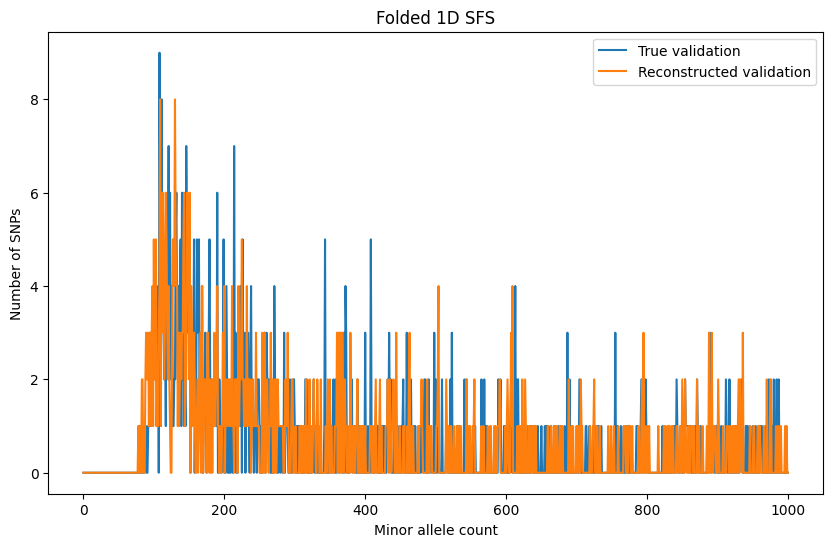

In [136]:
O = compute_folded_1d_sfs(G_true)
M = compute_folded_1d_sfs(G_recon)

plt.figure(figsize=(10, 6))
plt.plot(O, label="True validation")
plt.plot(M, label="Reconstructed validation")
plt.xlabel("Minor allele count")
plt.ylabel("Number of SNPs")
plt.title("Folded 1D SFS")
plt.legend()
plt.show()

In [137]:
from scipy.special import gammaln

def poisson_log_likelihood(O, M, eps=1e-10):
    O = O.astype(float)
    M = M.astype(float)
    M = M * (O.sum() / M.sum())   # rescale
    M = M + eps
    return np.sum(O * np.log(M) - M - gammaln(O + 1))

# optional: polymorphic bins only
O_poly = O[1:]
M_poly = M[1:]

logL = poisson_log_likelihood(O_poly, M_poly)
print("Poisson log-likelihood:", logL)

Poisson log-likelihood: -6366.823956172414


In [138]:
logL_self = poisson_log_likelihood(O_poly, O_poly)
print("Self log-likelihood:", logL_self)

Self log-likelihood: -478.5772157514088


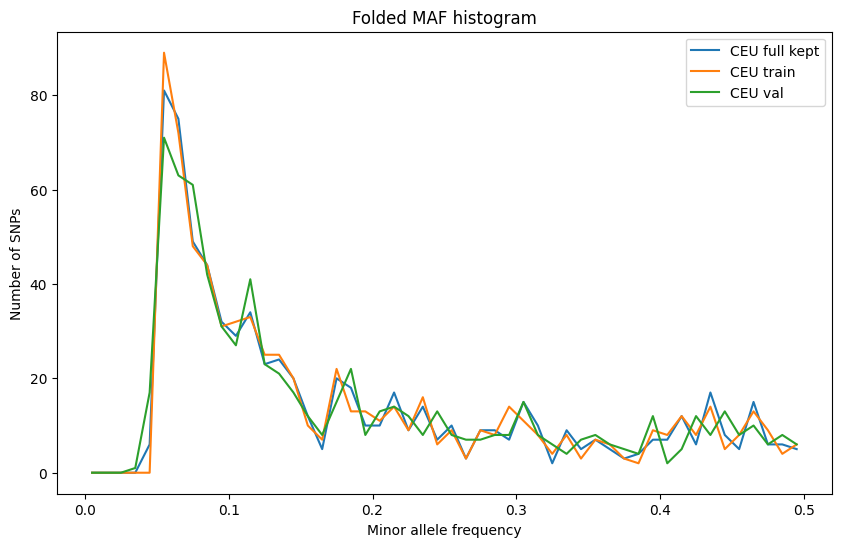

In [139]:
import numpy as np
import matplotlib.pyplot as plt

def folded_maf_per_snp(G):
    n = G.shape[0]
    n_chrom = 2 * n
    allele_counts = G.sum(axis=0)
    minor_counts = np.minimum(allele_counts, n_chrom - allele_counts)
    maf = minor_counts / n_chrom
    return maf

def maf_histogram(G, bins):
    maf = folded_maf_per_snp(G)
    hist, edges = np.histogram(maf, bins=bins)
    centers = 0.5 * (edges[:-1] + edges[1:])
    return centers, hist

bins = np.linspace(0, 0.5, 51)

G_train = np.load("/sietch_colab/akapoor/XPopVAE/experiments/IM_symmetric/processed_data/0/rep0/discovery_train.npy")
G_val = np.load("/sietch_colab/akapoor/XPopVAE/experiments/IM_symmetric/processed_data/0/rep0/discovery_val.npy")
G_ceu_full = np.concatenate([G_train, G_val], axis=0)

x_train, h_train = maf_histogram(G_train, bins)
x_val, h_val = maf_histogram(G_val, bins)
x_full, h_full = maf_histogram(G_ceu_full, bins)

plt.figure(figsize=(10, 6))
plt.plot(x_full, h_full, label="CEU full kept")
plt.plot(x_train, h_train, label="CEU train")
plt.plot(x_val, h_val, label="CEU val")
plt.xlabel("Minor allele frequency")
plt.ylabel("Number of SNPs")
plt.title("Folded MAF histogram")
plt.legend()
plt.show()